In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest

In [ ]:
df = pd.read_csv('/content/iot_sensor_data.csv')

In [ ]:
df.head()

,Reading_ID,Timestamp,Machine_ID,Equipment_Type,Location,Shift,Temperature,Pressure,Vibration,Humidity,...,Ambient_Temp,Oil_Level,Noise_Level,Uptime_Hours,Downtime_Hours,Production_Count,Defect_Count,Sensor_ID,Firmware_Version,Anomaly_Flag
0,RD728470,2024-03-02 10:03:00,MCH302,Hydraulic Press,Unit 1,Day,62.86,4.17,NaN,42.03,...,28.28,93.29,79.58,7590,82,541,7,SEN5727,V3.1.1,0
1,RD784570,2024-05-19 13:30:00,MCH357,Motor,Warehouse 2,Afternoon,74.31,4.19,49.24,54.03,...,28.00,96.86,42.56,7928,41,276,1,SEN9149,V5.0.7,1
2,RD244108,2024-03-14 22:39:00,MCH300,Hydraulic Press,Unit 3,Morning,49.50,2.51,48.91,67.51,...,22.47,21.20,64.39,7231,393,586,3,SEN5267,V2.4.0,0
3,RD530072,2024-05-13 11:42:00,MCH144,Generator,Warehouse 1,Day,80.31,8.54,23.76,44.63,...,42.38,53.10,67.82,2910,178,192,4,SEN3746,V3.0.6,1
4,RD459255,2024-02-05 23:46:00,MCH652,Generator,Plant B,Day,29.66,1.86,25.93,45.83,...,23.95,64.61,71.41,1699,481,229,9,SEN4444,V2.3.3,0


In [ ]:
df.shape

(25700, 30)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25700 entries, 0 to 25699
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Reading_ID             25700 non-null  object 
 1   Timestamp              25700 non-null  object 
 2   Machine_ID             25700 non-null  object 
 3   Equipment_Type         25700 non-null  object 
 4   Location               25700 non-null  object 
 5   Shift                  25639 non-null  object 
 6   Temperature            24901 non-null  float64
 7   Pressure               25087 non-null  float64
 8   Vibration              24994 non-null  float64
 9   Humidity               25184 non-null  float64
 10  Voltage                25083 non-null  float64
 11  Current                25700 non-null  float64
 12  RPM                    25700 non-null  int64  
 13  Power_Consumption      25543 non-null  float64
 14  Machine_Status         25619 non-null  object 
 15  Ag

In [ ]:
df.describe()

,Temperature,Pressure,Vibration,Humidity,Voltage,Current,RPM,Power_Consumption,Age_Years,Last_Maintenance_Days,Operating_Hours,Load_Percent,Ambient_Temp,Oil_Level,Noise_Level,Uptime_Hours,Downtime_Hours,Production_Count,Defect_Count
count,24901.000000,25087.000000,24994.000000,25184.000000,25083.000000,25700.000000,25700.000000,25543.000000,25700.000000,25700.000000,25700.000000,25538.000000,25700.000000,25544.000000,25554.000000,25700.000000,25700.000000,25700.000000,25700.000000
mean,60.336544,7.391032,30.372797,60.050887,224.867989,27.404567,2150.017588,25.213588,10.563891,45.153852,11.984008,60.074577,29.923682,59.846179,70.019317,5060.316732,250.371401,500.038872,5.028716
std,88.169814,29.493261,71.997402,17.307011,14.389788,12.917659,2644.714507,14.306253,5.776726,26.356374,7.217937,23.142863,8.662800,23.114377,17.282769,2862.751097,145.158158,289.834594,3.153324
min,-999.000000,-10.000000,-100.000000,30.000000,200.010000,5.000000,-500.000000,0.500000,1.000000,0.000000,0.000000,20.000000,15.000000,20.000000,40.000000,100.000000,0.000000,0.000000,0.000000
25%,39.150000,3.200000,12.172500,45.237500,212.375000,16.330000,1499.000000,12.805000,6.000000,22.000000,6.000000,40.010000,22.460000,39.610000,55.090000,2548.000000,125.000000,249.000000,2.000000
50%,59.390000,5.470000,25.060000,59.995000,224.810000,27.400000,2004.000000,25.250000,11.000000,45.000000,12.000000,60.175000,29.855000,59.805000,70.030000,5078.000000,250.000000,498.000000,5.000000
75%,79.750000,7.770000,37.810000,74.940000,237.330000,38.482500,2512.000000,37.530000,16.000000,68.000000,18.000000,80.197500,37.390000,80.040000,84.940000,7544.250000,376.000000,750.250000,8.000000
max,999.000000,500.000000,1000.000000,90.000000,250.000000,50.000000,50000.000000,50.000000,20.000000,90.000000,24.000000,100.000000,45.000000,100.000000,100.000000,10000.000000,500.000000,1000.000000,10.000000


In [ ]:
df.isnull().sum()

,0
Reading_ID,0
Timestamp,0
Machine_ID,0
Equipment_Type,0
Location,0
Shift,61
Temperature,799
Pressure,613
Vibration,706
Humidity,516


In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.columns

Index(['Reading_ID', 'Timestamp', 'Machine_ID', 'Equipment_Type', 'Location',
       'Shift', 'Temperature', 'Pressure', 'Vibration', 'Humidity', 'Voltage',
       'Current', 'RPM', 'Power_Consumption', 'Machine_Status', 'Age_Years',
       'Maintenance_Due', 'Last_Maintenance_Days', 'Operating_Hours',
       'Load_Percent', 'Ambient_Temp', 'Oil_Level', 'Noise_Level',
       'Uptime_Hours', 'Downtime_Hours', 'Production_Count', 'Defect_Count',
       'Sensor_ID', 'Firmware_Version', 'Anomaly_Flag'],
      dtype='object')

EDA

In [ ]:
print("Rows and Columns:", df.shape)

Rows and Columns: (25700, 30)


In [ ]:
df.dtypes

,0
Reading_ID,object
Timestamp,object
Machine_ID,object
Equipment_Type,object
Location,object
Shift,object
Temperature,float64
Pressure,float64
Vibration,float64
Humidity,float64


In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns

print(numerical_cols)

Index(['Temperature', 'Pressure', 'Vibration', 'Humidity', 'Voltage',
       'Current', 'RPM', 'Power_Consumption', 'Age_Years',
       'Last_Maintenance_Days', 'Operating_Hours', 'Load_Percent',
       'Ambient_Temp', 'Oil_Level', 'Noise_Level', 'Uptime_Hours',
       'Downtime_Hours', 'Production_Count', 'Defect_Count'],
      dtype='object')


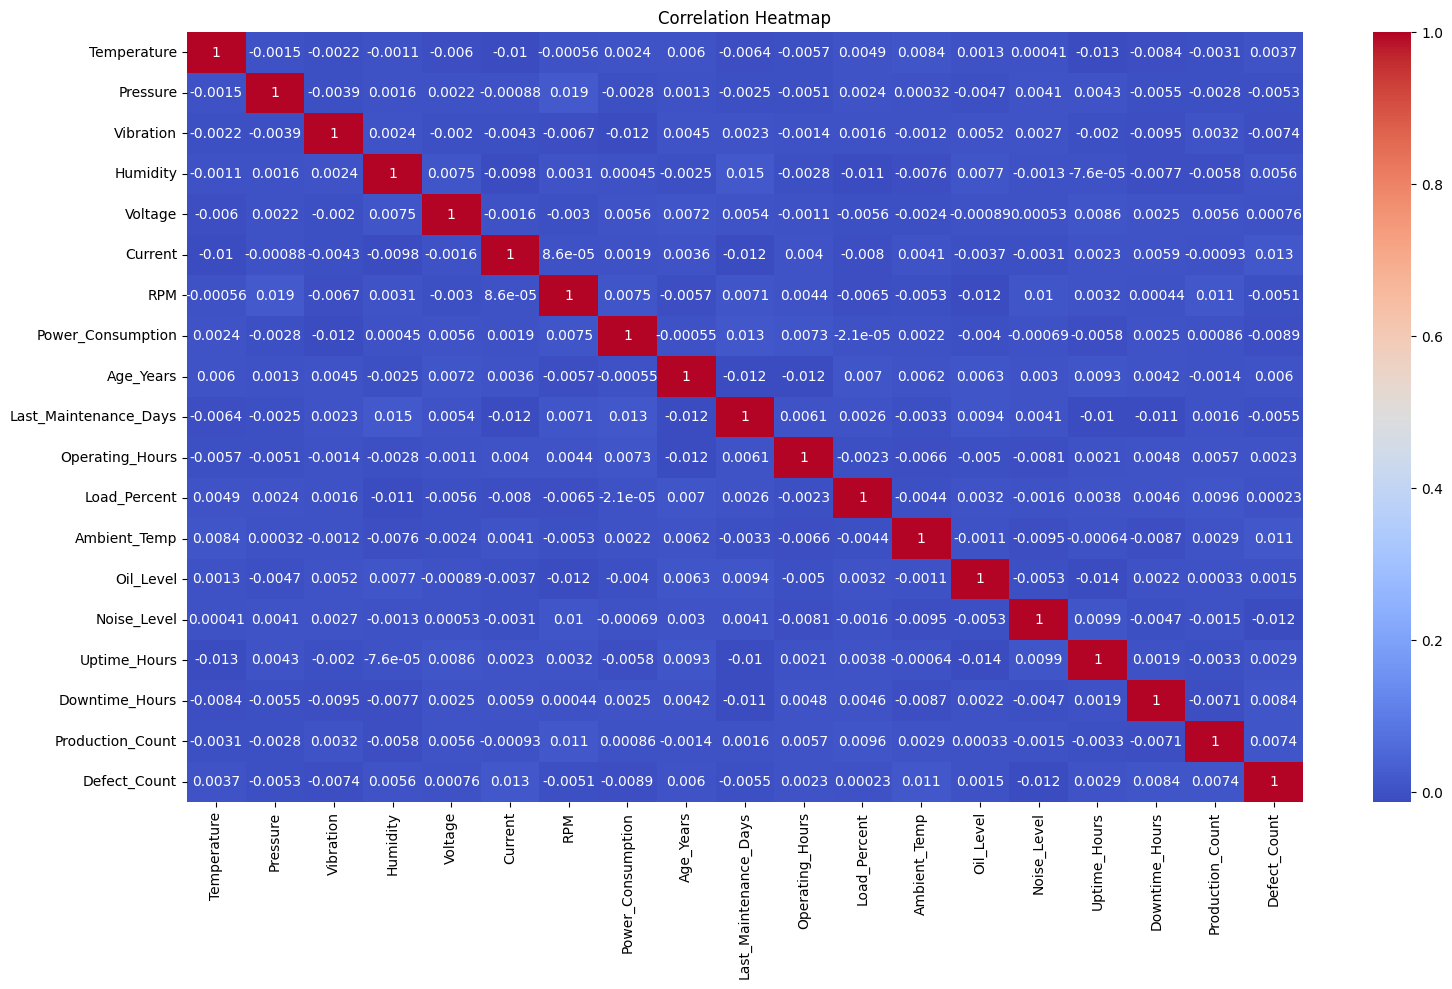

In [ ]:
plt.figure(figsize=(18,10))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

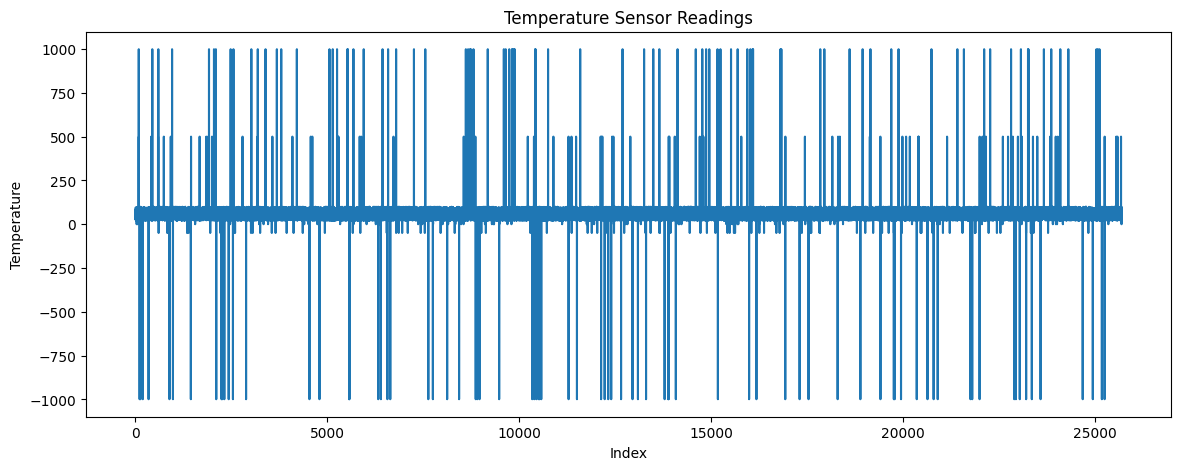

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(df['Temperature'])

plt.title("Temperature Sensor Readings")
plt.xlabel("Index")
plt.ylabel("Temperature")

plt.show()

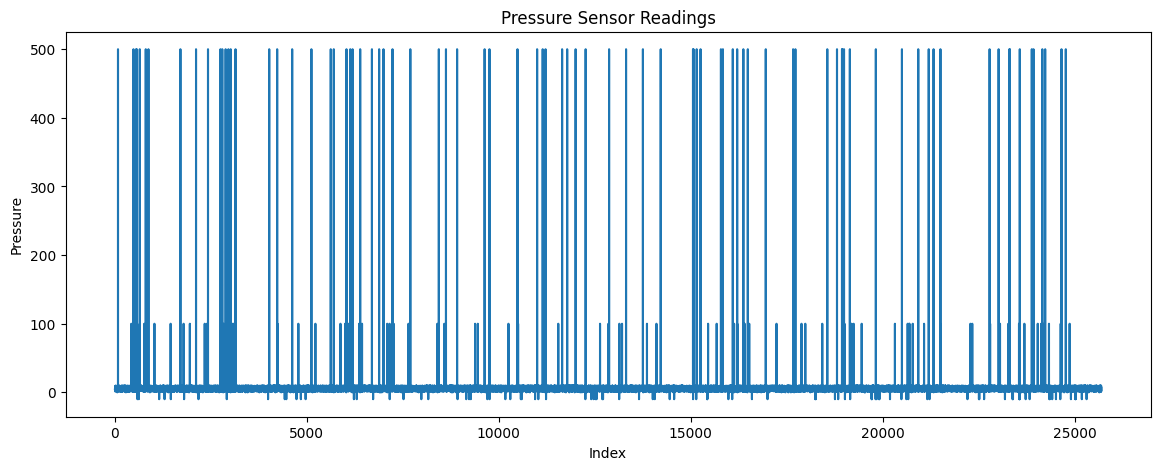

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(df['Pressure'])

plt.title("Pressure Sensor Readings")
plt.xlabel("Index")
plt.ylabel("Pressure")

plt.show()

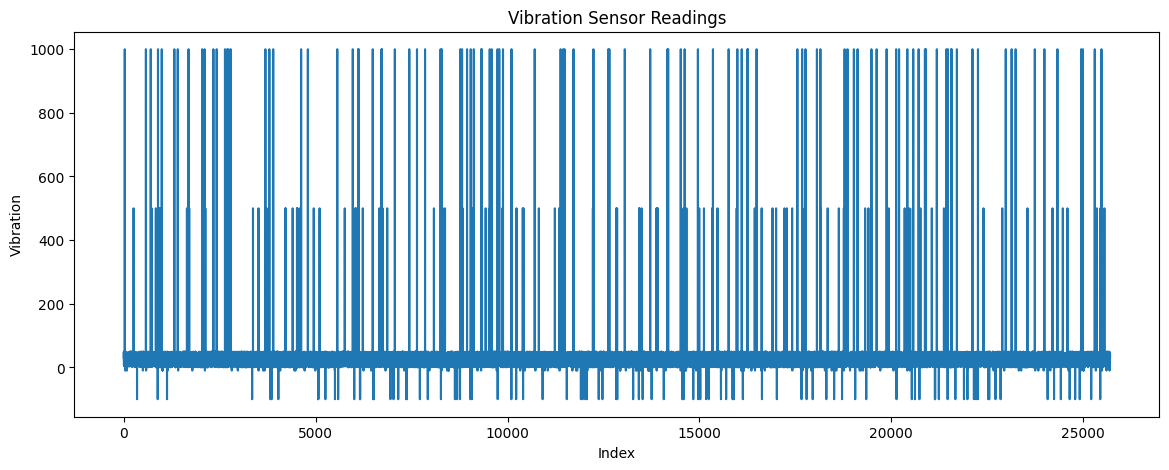

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(df['Vibration'])

plt.title("Vibration Sensor Readings")
plt.xlabel("Index")
plt.ylabel("Vibration")

plt.show()

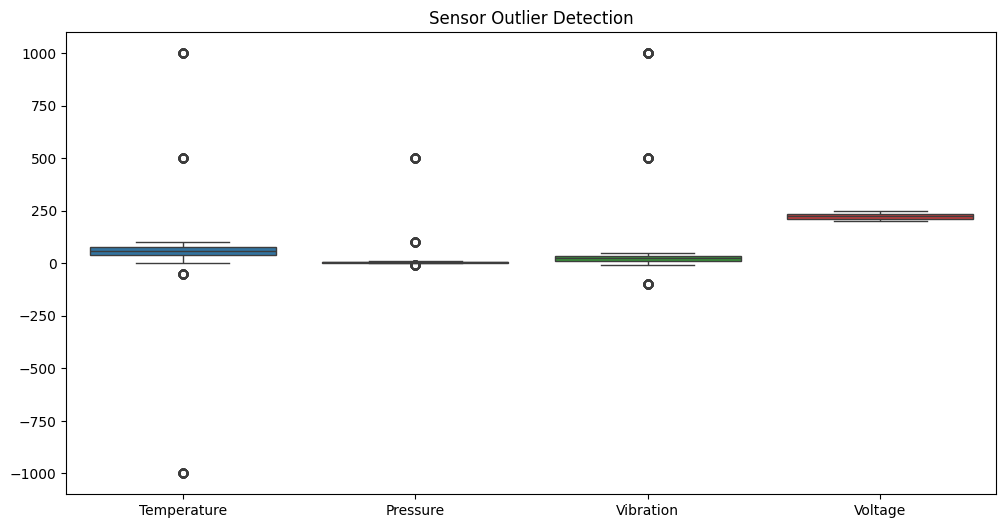

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df[['Temperature','Pressure','Vibration','Voltage']])

plt.title("Sensor Outlier Detection")
plt.show()

In [ ]:
Anomaly_Flag

NameError: name 'Anomaly_Flag' is not defined

In [ ]:
df['Anomaly_Flag'].value_counts()

,count
Anomaly_Flag,
0,20383
1,5003
false,67
TRUE,66
FALSE,60
true,55


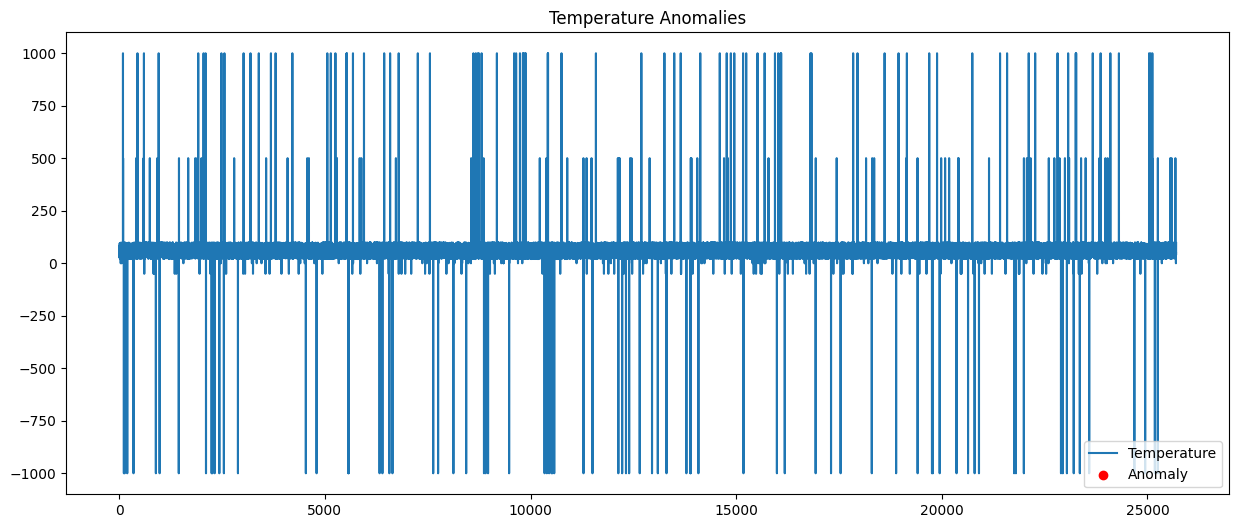

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(df['Temperature'], label='Temperature')

anomalies = df[df['Anomaly_Flag'] == 1]

plt.scatter(
    anomalies.index,
    anomalies['Temperature'],
    color='red',
    label='Anomaly'
)

plt.legend()
plt.title("Temperature Anomalies")
plt.show()

In [ ]:
df['Anomaly_Flag'].value_counts()

,count
Anomaly_Flag,
0,20383
1,5003
false,67
TRUE,66
FALSE,60
true,55


In [ ]:
df['Anomaly_Flag'] = df['Anomaly_Flag'].replace({
    'true': 1,
    'TRUE': 1,
    True: 1,

    'false': 0,
    'FALSE': 0,
    False: 0
})

In [ ]:
df['Anomaly_Flag'] = df['Anomaly_Flag'].astype(int)

ValueError: cannot convert float NaN to integer

In [ ]:
df['Anomaly_Flag'].value_counts()

,count
Anomaly_Flag,
0,20383
1,5003
0,127
1,121


In [ ]:
df['Anomaly_Flag'].unique()

array(['0', '1', 1, nan, 0], dtype=object)

In [ ]:
df['Anomaly_Flag'] = (
    df['Anomaly_Flag']
    .astype(str)
    .str.strip()
    .str.lower()
)

In [ ]:
df['Anomaly_Flag'] = df['Anomaly_Flag'].replace({
    'true': 1,
    'false': 0,
    '1': 1,
    '0': 0
})

In [ ]:
df['Anomaly_Flag'].isnull().sum()

np.int64(0)

In [ ]:
df = df.dropna(subset=['Anomaly_Flag'])

In [ ]:
df['Anomaly_Flag'] = df['Anomaly_Flag'].astype(int)

ValueError: invalid literal for int() with base 10: 'nan'

In [ ]:
df['Anomaly_Flag'].value_counts()

,count
Anomaly_Flag,
0,20510
1,5124
nan,66


In [ ]:
df = df[df['Anomaly_Flag'] != 'nan']

In [ ]:
df = df.dropna(subset=['Anomaly_Flag'])

In [ ]:
df['Anomaly_Flag'] = df['Anomaly_Flag'].astype(int)

In [ ]:
df['Anomaly_Flag'].value_counts()

,count
Anomaly_Flag,
0,20510
1,5124


ML MODEL

In [ ]:
features = df[[
    'Temperature',
    'Pressure',
    'Vibration',
    'Humidity',
    'Voltage',
    'Current',
    'RPM',
    'Power_Consumption',
    'Load_Percent',
    'Noise_Level'
]]

In [ ]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    contamination=0.20,
    random_state=42
)

model.fit(features)

IsolationForest(contamination=0.2, random_state=42)

In [ ]:
df['Predicted_Anomaly'] = model.predict(features)

In [ ]:
df['Predicted_Anomaly'] = df['Predicted_Anomaly'].map({
    1: 0,
    -1: 1
})

In [ ]:
df[['Anomaly_Flag', 'Predicted_Anomaly']].head(20)

,Anomaly_Flag,Predicted_Anomaly
0,0,0
1,1,0
2,0,0
3,1,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    df['Anomaly_Flag'],
    df['Predicted_Anomaly']
))

              precision    recall  f1-score   support

           0       0.80      0.80      0.80     20510
           1       0.20      0.20      0.20      5124

    accuracy                           0.68     25634
   macro avg       0.50      0.50      0.50     25634
weighted avg       0.68      0.68      0.68     25634



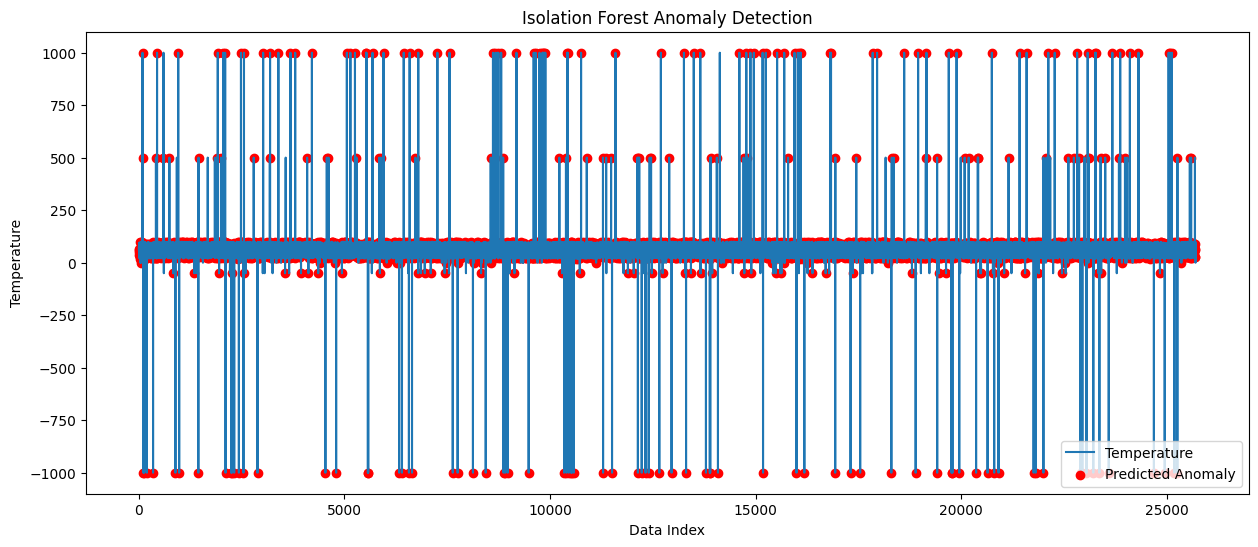

In [ ]:
predicted_anomalies = df[df['Predicted_Anomaly'] == 1]

plt.figure(figsize=(15,6))

plt.plot(df['Temperature'], label='Temperature')

plt.scatter(
    predicted_anomalies.index,
    predicted_anomalies['Temperature'],
    color='red',
    label='Predicted Anomaly'
)

plt.legend()

plt.title("Isolation Forest Anomaly Detection")

plt.xlabel("Data Index")
plt.ylabel("Temperature")

plt.show()

FEATURE ENGINEERING

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest

In [4]:
df = pd.read_csv('/content/iot_sensor_data.csv')

In [5]:
df.head()

,Reading_ID,Timestamp,Machine_ID,Equipment_Type,Location,Shift,Temperature,Pressure,Vibration,Humidity,...,Ambient_Temp,Oil_Level,Noise_Level,Uptime_Hours,Downtime_Hours,Production_Count,Defect_Count,Sensor_ID,Firmware_Version,Anomaly_Flag
0,RD728470,2024-03-02 10:03:00,MCH302,Hydraulic Press,Unit 1,Day,62.86,4.17,NaN,42.03,...,28.28,93.29,79.58,7590,82,541,7,SEN5727,V3.1.1,0
1,RD784570,2024-05-19 13:30:00,MCH357,Motor,Warehouse 2,Afternoon,74.31,4.19,49.24,54.03,...,28.00,96.86,42.56,7928,41,276,1,SEN9149,V5.0.7,1
2,RD244108,2024-03-14 22:39:00,MCH300,Hydraulic Press,Unit 3,Morning,49.50,2.51,48.91,67.51,...,22.47,21.20,64.39,7231,393,586,3,SEN5267,V2.4.0,0
3,RD530072,2024-05-13 11:42:00,MCH144,Generator,Warehouse 1,Day,80.31,8.54,23.76,44.63,...,42.38,53.10,67.82,2910,178,192,4,SEN3746,V3.0.6,1
4,RD459255,2024-02-05 23:46:00,MCH652,Generator,Plant B,Day,29.66,1.86,25.93,45.83,...,23.95,64.61,71.41,1699,481,229,9,SEN4444,V2.3.3,0


In [6]:
df['Anomaly_Flag'] = (
    df['Anomaly_Flag']
    .astype(str)
    .str.strip()
    .str.lower()
)

df['Anomaly_Flag'] = df['Anomaly_Flag'].replace({
    'true': 1,
    'false': 0,
    '1': 1,
    '0': 0
})

df = df[df['Anomaly_Flag'] != 'nan']

df = df.dropna(subset=['Anomaly_Flag'])

df['Anomaly_Flag'] = df['Anomaly_Flag'].astype(int)

In [7]:
df['Anomaly_Flag'].value_counts()

,count
Anomaly_Flag,
0,20510
1,5124


In [8]:
df['Temp_Rolling_Mean'] = (
    df['Temperature']
    .rolling(window=5)
    .mean()
)

df['Temp_Rolling_STD'] = (
    df['Temperature']
    .rolling(window=5)
    .std()
)

df['Pressure_Rolling_Mean'] = (
    df['Pressure']
    .rolling(window=5)
    .mean()
)

df['Vibration_Rolling_Mean'] = (
    df['Vibration']
    .rolling(window=5)
    .mean()
)

In [9]:
df.bfill(inplace=True)

In [10]:
df.head()

,Reading_ID,Timestamp,Machine_ID,Equipment_Type,Location,Shift,Temperature,Pressure,Vibration,Humidity,...,Downtime_Hours,Production_Count,Defect_Count,Sensor_ID,Firmware_Version,Anomaly_Flag,Temp_Rolling_Mean,Temp_Rolling_STD,Pressure_Rolling_Mean,Vibration_Rolling_Mean
0,RD728470,2024-03-02 10:03:00,MCH302,Hydraulic Press,Unit 1,Day,62.86,4.17,49.24,42.03,...,82,541,7,SEN5727,V3.1.1,0,59.328,20.33445,4.254,32.372
1,RD784570,2024-05-19 13:30:00,MCH357,Motor,Warehouse 2,Afternoon,74.31,4.19,49.24,54.03,...,41,276,1,SEN9149,V5.0.7,1,59.328,20.33445,4.254,32.372
2,RD244108,2024-03-14 22:39:00,MCH300,Hydraulic Press,Unit 3,Morning,49.50,2.51,48.91,67.51,...,393,586,3,SEN5267,V2.4.0,0,59.328,20.33445,4.254,32.372
3,RD530072,2024-05-13 11:42:00,MCH144,Generator,Warehouse 1,Day,80.31,8.54,23.76,44.63,...,178,192,4,SEN3746,V3.0.6,1,59.328,20.33445,4.254,32.372
4,RD459255,2024-02-05 23:46:00,MCH652,Generator,Plant B,Day,29.66,1.86,25.93,45.83,...,481,229,9,SEN4444,V2.3.3,0,59.328,20.33445,4.254,32.372


ADVANCE MODELING

In [11]:
advanced_features = df[[
    'Temperature',
    'Pressure',
    'Vibration',
    'Humidity',
    'Voltage',
    'Current',
    'RPM',
    'Power_Consumption',
    'Load_Percent',
    'Noise_Level',

    'Temp_Rolling_Mean',
    'Temp_Rolling_STD',
    'Pressure_Rolling_Mean',
    'Vibration_Rolling_Mean'
]]

In [12]:
advanced_model = IsolationForest(
    contamination=0.20,
    random_state=42
)

advanced_model.fit(advanced_features)

IsolationForest(contamination=0.2, random_state=42)

In [13]:
df['Advanced_Predicted_Anomaly'] = (
    advanced_model.predict(advanced_features)
)

In [14]:
df['Advanced_Predicted_Anomaly'] = (
    df['Advanced_Predicted_Anomaly']
    .map({1: 0, -1: 1})
)

In [15]:
df[[
    'Anomaly_Flag',
    'Advanced_Predicted_Anomaly'
]].head(20)

,Anomaly_Flag,Advanced_Predicted_Anomaly
0,0,0
1,1,0
2,0,0
3,1,0
4,0,0
5,0,0
6,0,0
7,0,1
8,0,0
9,0,0


In [16]:
from sklearn.metrics import classification_report

print(classification_report(
    df['Anomaly_Flag'],
    df['Advanced_Predicted_Anomaly']
))

              precision    recall  f1-score   support

           0       0.80      0.80      0.80     20510
           1       0.21      0.21      0.21      5124

    accuracy                           0.68     25634
   macro avg       0.51      0.51      0.51     25634
weighted avg       0.68      0.68      0.68     25634



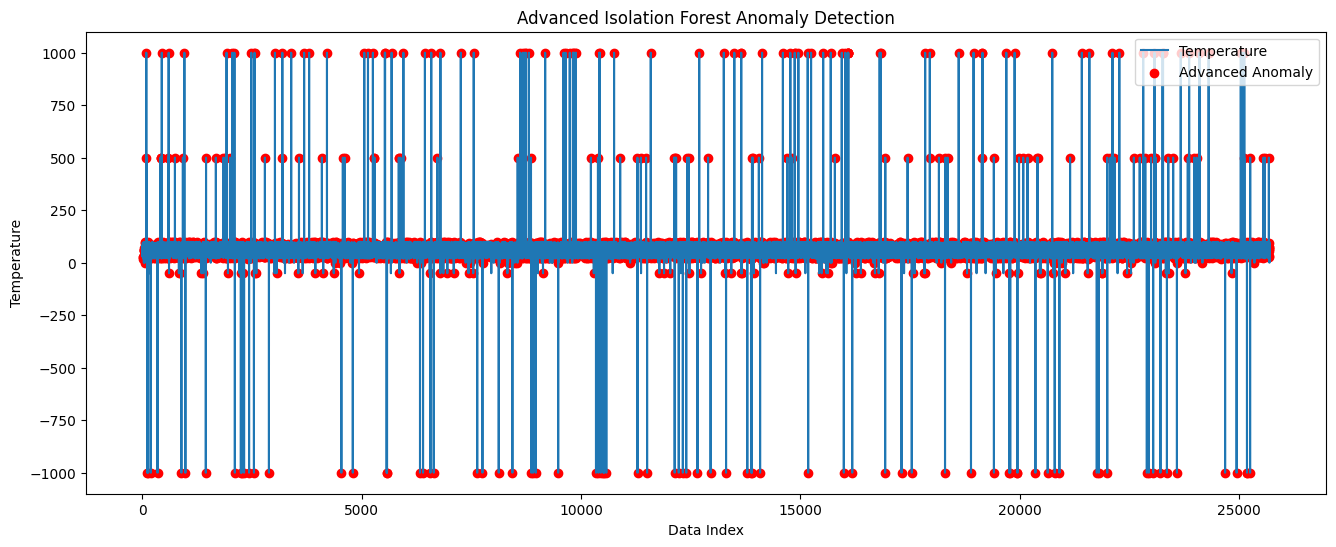

In [17]:
advanced_anomalies = df[
    df['Advanced_Predicted_Anomaly'] == 1
]

plt.figure(figsize=(16,6))

plt.plot(
    df['Temperature'],
    label='Temperature'
)

plt.scatter(
    advanced_anomalies.index,
    advanced_anomalies['Temperature'],
    color='red',
    label='Advanced Anomaly'
)

plt.legend()

plt.title(
    "Advanced Isolation Forest Anomaly Detection"
)

plt.xlabel("Data Index")
plt.ylabel("Temperature")

plt.show()

In [18]:
df.to_csv(
    'final_iot_anomaly_dataset.csv',
    index=False
)

FEATURE SCALING

In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    advanced_features
)

In [21]:
scaled_model = IsolationForest(
    contamination=0.20,
    random_state=42
)

scaled_model.fit(scaled_features)

IsolationForest(contamination=0.2, random_state=42)

In [22]:
df['Scaled_Predicted_Anomaly'] = (
    scaled_model.predict(scaled_features)
)

In [23]:
df['Scaled_Predicted_Anomaly'] = (
    df['Scaled_Predicted_Anomaly']
    .map({1: 0, -1: 1})
)

In [24]:
print(classification_report(
    df['Anomaly_Flag'],
    df['Scaled_Predicted_Anomaly']
))

              precision    recall  f1-score   support

           0       0.80      0.80      0.80     20510
           1       0.21      0.21      0.21      5124

    accuracy                           0.68     25634
   macro avg       0.51      0.51      0.51     25634
weighted avg       0.68      0.68      0.68     25634



AUTO ENCODER NEURAL NETWORK

In [25]:
!pip install tensorflow

In [26]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import StandardScaler

In [27]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    advanced_features
)

In [28]:
input_dim = scaled_data.shape[1]

In [29]:
input_layer = Input(shape=(input_dim,))

encoder = Dense(32, activation='relu')(input_layer)
encoder = Dense(16, activation='relu')(encoder)

decoder = Dense(32, activation='relu')(encoder)
decoder = Dense(input_dim, activation='linear')(decoder)

autoencoder = Model(
    inputs=input_layer,
    outputs=decoder
)

In [30]:
autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

In [31]:
history = autoencoder.fit(
    scaled_data,
    scaled_data,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.5020 - val_loss: 0.1481
Epoch 2/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0810 - val_loss: 0.0440
Epoch 3/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0355 - val_loss: 0.0264
Epoch 4/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0240 - val_loss: 0.0195
Epoch 5/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0190 - val_loss: 0.0161
Epoch 6/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0153 - val_loss: 0.0128
Epoch 7/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0126 - val_loss: 0.0105
Epoch 8/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0107 - val_loss: 0.0108
Epoch 9/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0088 - val_loss: 0.0076
Epoch 10/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0067 - val_loss: 0.0064
Epoch 11/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0055 - val_loss: 0.0062
Epoch 12/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

In [32]:
reconstructed_data = autoencoder.predict(
    scaled_data
)

802/802 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [33]:
mse = np.mean(
    np.power(
        scaled_data - reconstructed_data,
        2
    ),
    axis=1
)

In [34]:
df['Reconstruction_Error'] = mse

In [35]:
threshold = np.percentile(mse, 80)

In [36]:
df['Autoencoder_Anomaly'] = (
    df['Reconstruction_Error'] > threshold
).astype(int)

In [37]:
print(classification_report(
    df['Anomaly_Flag'],
    df['Autoencoder_Anomaly']
))

              precision    recall  f1-score   support

           0       0.80      0.80      0.80     20510
           1       0.21      0.21      0.21      5124

    accuracy                           0.68     25634
   macro avg       0.51      0.51      0.51     25634
weighted avg       0.68      0.68      0.68     25634

